# Hate Speech Detection - Machine Learning Pipeline

This notebook implements a complete ML pipeline for hate speech detection using classical machine learning techniques.

## Pipeline Overview
1. **Data Preprocessing**: Text cleaning, normalization, stopword removal
2. **Feature Engineering**: TF-IDF Vectorization
3. **Model Training**: Logistic Regression, Naive Bayes, SVM
4. **Model Selection**: Best model based on F1-score
5. **Evaluation**: Precision, Recall, F1-score

## 1. Import Libraries

In [1]:
import re
import string
import pickle
import json
from pathlib import Path

import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Configuration

In [2]:
# Random state for reproducibility
RANDOM_STATE = 42

# Paths
DATA_DIR = Path("data")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

# Dataset file
DATA_PATH = DATA_DIR / "HateSpeechDatasetBalanced.csv"

print(f"Data path: {DATA_PATH}")
print(f"Models directory: {MODELS_DIR}")

Data path: data\HateSpeechDatasetBalanced.csv
Models directory: models


## 3. Data Loading

In [3]:
# Load the dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (726119, 2)

Column names: ['Content', 'Label']

First 5 rows:


,Content,Label
0,denial of normal the con be asked to comment o...,1
1,just by being able to tweet this insufferable ...,1
2,that is retarded you too cute to be single tha...,1
3,thought of a real badass mongol style declarat...,1
4,afro american basho,1


In [4]:
df.isnull().sum()

Content    0
Label      0
dtype: int64

In [10]:
# Check label distribution
print("Label distribution:")
print(df['Label'].value_counts())
print(f"\nPercentage:")
print(df['Label'].value_counts(normalize=True) * 100)

Label distribution:
Label
1    364525
0    361594
Name: count, dtype: int64

Percentage:
Label
1    50.201826
0    49.798174
Name: proportion, dtype: float64


## 5. Exploratory Data Analysis (EDA)

In [15]:
# Basic dataset information
print("Dataset Overview:")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Unique value counts
print(f"\nUnique values in 'Label': {df['Label'].nunique()}")
print(f"Label values: {sorted(df['Label'].unique())}")

Dataset Overview:
Shape: (726119, 2)

Columns: ['Content', 'Label']

Data Types:
Content    object
Label       int64
dtype: object

Missing Values:
Content    0
Label      0
dtype: int64

Duplicate Rows: 25046

Unique values in 'Label': 2
Label values: [np.int64(0), np.int64(1)]


Text Length Statistics:
Character count — Mean: 196.8, Median: 109.0, Max: 9998
Word count — Mean: 36.3, Median: 21.0, Max: 310

By Class:
      char_count                word_count              
            mean median     std       mean median    std
Label                                                   
0         245.06  130.0  290.45      44.94   25.0  51.99
1         149.02   95.0  183.30      27.80   18.0  32.62


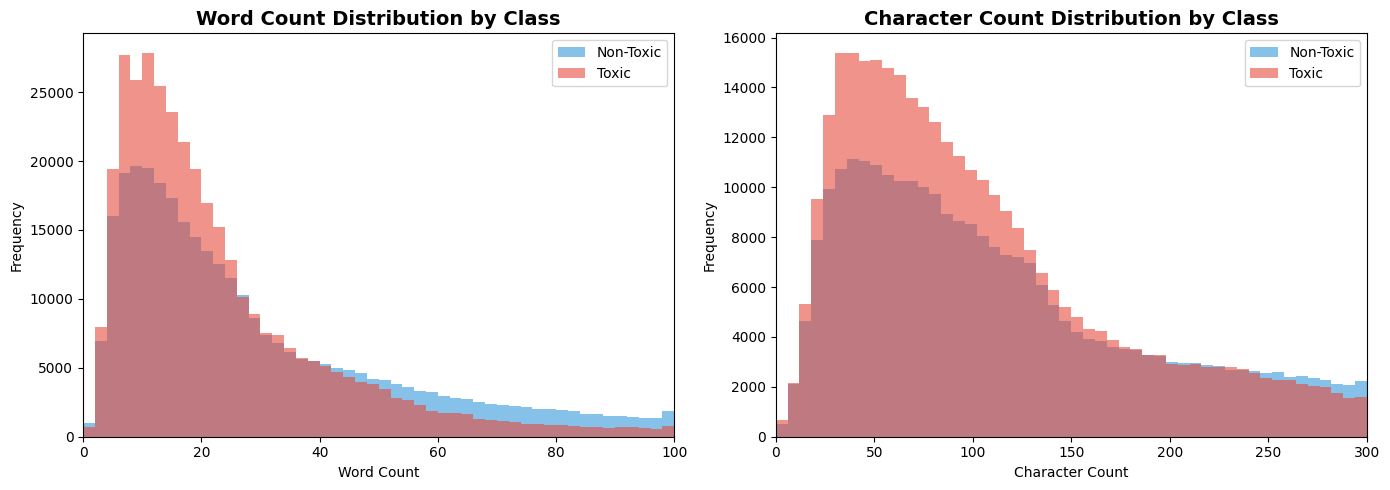

In [16]:
# Text length statistics
import matplotlib.pyplot as plt

# Calculate text lengths
# Use original text lengths before preprocessing for more realistic stats
df['char_count'] = df['Content'].astype(str).apply(len)
df['word_count'] = df['Content'].astype(str).apply(lambda x: len(str(x).split()))

# Summary statistics
print("Text Length Statistics:")
print("=" * 60)
print(f"Character count — Mean: {df['char_count'].mean():.1f}, Median: {df['char_count'].median():.1f}, Max: {df['char_count'].max()}")
print(f"Word count — Mean: {df['word_count'].mean():.1f}, Median: {df['word_count'].median():.1f}, Max: {df['word_count'].max()}")

# By class
print("\nBy Class:")
print(df.groupby('Label')[['char_count', 'word_count']].agg(['mean', 'median', 'std']).round(2))

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
for label, color, name in [(0, '#3498db', 'Non-Toxic'), (1, '#e74c3c', 'Toxic')]:
    subset = df[df['Label'] == label]['word_count']
    axes[0].hist(subset, bins=50, alpha=0.6, label=name, color=color, range=(0, 100))
axes[0].set_title('Word Count Distribution by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 100)

# Character count distribution
for label, color, name in [(0, '#3498db', 'Non-Toxic'), (1, '#e74c3c', 'Toxic')]:
    subset = df[df['Label'] == label]['char_count']
    axes[1].hist(subset, bins=50, alpha=0.6, label=name, color=color, range=(0, 300))
axes[1].set_title('Character Count Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

Top 20 words (overall):
  articl: 120373
  slut: 103496
  page: 98911
  fuck: 81177
  wikipedia: 71631
  edit: 70210
  use: 65072
  whatev: 61909
  talk: 60801
  pleas: 57013
  delet: 50234
  thank: 47476
  time: 46687
  sourc: 37613
  person: 32434
  mean: 31642
  bitch: 31591
  work: 30785
  name: 30273
  block: 29730

Top 15 words (Non-Toxic):
  articl: 107958
  page: 82126
  slut: 76800
  edit: 57066
  wikipedia: 53212
  use: 52252
  pleas: 47311
  talk: 46024
  delet: 42080
  thank: 40620
  whatev: 39888
  sourc: 33590
  time: 29958
  link: 22705
  remov: 22622

Top 15 words (Toxic):
  fuck: 68676
  slut: 26696
  whatev: 22021
  wikipedia: 18419
  bitch: 18315
  black: 18142
  women: 17988
  shit: 17848
  love: 17133
  page: 16785
  time: 16729
  call: 15562
  talk: 14777
  stop: 14702
  ass: 14295


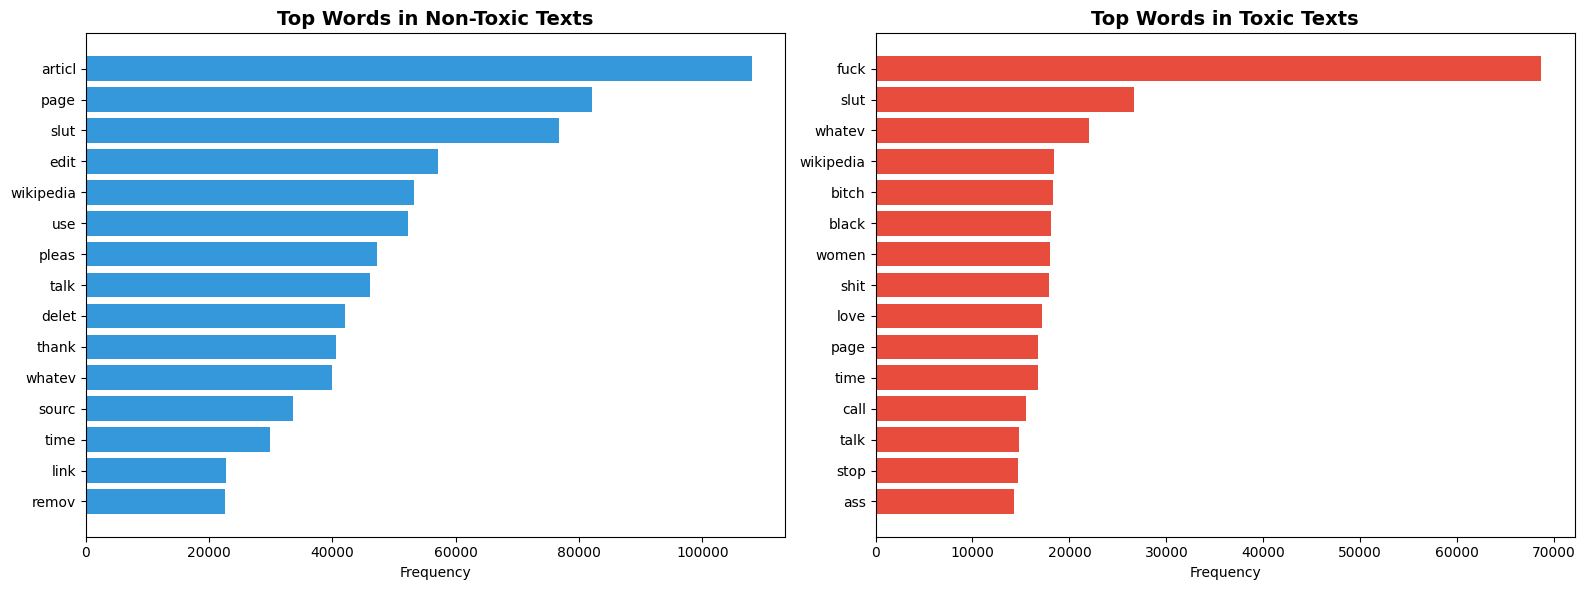

In [18]:
# Word frequency analysis
from collections import Counter

# Ensure processed_text exists (in case preprocessing cell hasn't been run yet)
if 'processed_text' not in df.columns:
    df['processed_text'] = df['Content'].apply(preprocess_text)

def get_word_freq(texts, top_n=20):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(top_n)

# Overall top words
overall_top = get_word_freq(df['processed_text'].dropna().tolist(), top_n=20)

# Top words by class
non_toxic_texts = df[df['Label'] == 0]['processed_text'].dropna().tolist()
toxic_texts = df[df['Label'] == 1]['processed_text'].dropna().tolist()

non_toxic_top = get_word_freq(non_toxic_texts, top_n=15)
toxic_top = get_word_freq(toxic_texts, top_n=15)

print("Top 20 words (overall):")
for word, count in overall_top:
    print(f"  {word}: {count}")

print("\nTop 15 words (Non-Toxic):")
for word, count in non_toxic_top:
    print(f"  {word}: {count}")

print("\nTop 15 words (Toxic):")
for word, count in toxic_top:
    print(f"  {word}: {count}")

# Visualize top words
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Non-toxic words
words_nt, counts_nt = zip(*non_toxic_top) if non_toxic_top else ([], [])
axes[0].barh(list(reversed(words_nt)), list(reversed(counts_nt)), color='#3498db')
axes[0].set_title('Top Words in Non-Toxic Texts', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Toxic words
words_t, counts_t = zip(*toxic_top) if toxic_top else ([], [])
axes[1].barh(list(reversed(words_t)), list(reversed(counts_t)), color='#e74c3c')
axes[1].set_title('Top Words in Toxic Texts', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [11]:
# Custom stopwords list
CUSTOM_STOPWORDS = {
    # contractions without apostrophes
    "dont", "wont", "cant", "isnt", "arent", "wasnt", "werent",
    "hasnt", "havent", "hadnt", "doesnt", "didnt", "couldnt",
    "wouldnt", "shouldnt", "mightnt", "mustnt", "shan", "aint",
    "thats", "whats", "theres", "heres", "wheres", "whens",
    "whos", "whys", "hows", "shes", "hes", "its", "theyre",
    "weve", "youve", "ive", "youre", "theyve", "shouldve",
    "wouldve", "couldve", "gonna", "wanna", "gotta", "kinda",
    "sorta", "dunno", "lemme", "gimme", "coulda", "woulda",
    "shoulda", "oughta", "hafta", "tryna", "boutta", "ya",
    "yall", "yea", "yeah", "nah", "tho", "tht", "lol",
    "lmao", "lmfao", "omg", "smh", "tbh", "imo", "btw",
    "fyi", "idk", "ikr", "iirc", "afaik", "irl", "rn",
    "af", "ur", "u", "r", "b4", "gr8", "luv", "msg",
    "pls", "plz", "thx", "tx", "ty", "np", "yw",
    "im", "ill", "ive", "id", "youre", "youve", "youll",
    "youd", "hes", "hed", "hell", "shes", "shed", "shell",
    "its", "itd", "itll", "were", "weve", "well", "wed",
    "theyre", "theyve", "theyll", "theyd","get", "got","go", "going", "gone", "come", "came",
    "like", "just", "really", "even", "still", "also", "would", "could",
    "one", "much", "make", "made", "want", "need", "say", "said",
    "thing", "things", "people", "know", "think", "see", "look",
    "back", "way", "well", "right", "good", "new", "take", "took",
}

# Standard stopwords + custom
STOP_WORDS = set(stopwords.words('english')).union(CUSTOM_STOPWORDS)

# Initialize stemmer
stemmer = PorterStemmer()

print(f"Total stopwords: {len(STOP_WORDS)}")

Total stopwords: 339


In [12]:
def preprocess_text(text):
    """
    Preprocess text for hate speech detection:
    1. Convert to lowercase
    2. Remove URLs, HTML tags, mentions, hashtags
    3. Normalize repeated characters
    4. Remove punctuation and special characters
    5. Tokenize and remove stopwords
    6. Apply Porter stemming
    """
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove mentions and hashtags
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#', '', text)
    
    # Normalize repeated characters (e.g., 'haaate' -> 'haate')
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and short tokens, then stem
    processed_tokens = [
        stemmer.stem(token) 
        for token in tokens 
        if token not in STOP_WORDS and len(token) >= 2
    ]
    
    return ' '.join(processed_tokens)

# Test preprocessing
test_text = "I don't think this is gonna work!!! Haaate this @user #bad"
print(f"Original: {test_text}")
print(f"Processed: {preprocess_text(test_text)}")

Original: I don't think this is gonna work!!! Haaate this @user #bad
Processed: gon na work haat bad


In [7]:
# Apply preprocessing to all texts
print("Preprocessing texts...")
df['processed_text'] = df['Content'].apply(preprocess_text)

# Remove empty texts
df = df[df['processed_text'].str.len() > 0].reset_index(drop=True)

print(f"Dataset shape after preprocessing: {df.shape}")
print("\nExample of original vs processed:")
for i in range(3):
    print(f"\nOriginal: {df['Content'].iloc[i]}")
    print(f"Processed: {df['processed_text'].iloc[i]}")

Preprocessing texts...
Dataset shape after preprocessing: (723890, 3)

Example of original vs processed:

Original: denial of normal the con be asked to comment on tragedies an emotional retard
Processed: denial normal con ask comment tragedi emot retard

Original: just by being able to tweet this insufferable bullshit proves trump a nazi you vagina
Processed: abl tweet insuffer bullshit prove trump nazi vagina

Original: that is retarded you too cute to be single that is life
Processed: retard cute singl life


## 5. Feature Engineering - TF-IDF Vectorization

In [8]:
# Split data into train and test
X = df['processed_text']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining label distribution:")
print(y_train.value_counts(normalize=True))

Training set size: 579112
Test set size: 144778

Training label distribution:
Label
1    0.501535
0    0.498465
Name: proportion, dtype: float64


In [9]:
# Feature Engineering: FeatureUnion combining word-level and character-level TF-IDF
# Word n-grams capture semantic meaning; character n-grams capture
# morphological patterns and are robust to misspellings common in toxic text.
from sklearn.pipeline import FeatureUnion

tfidf_vectorizer = FeatureUnion([
    ('word', TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        max_features=12000,
        sublinear_tf=True,
        min_df=5,
        max_df=0.95,
    )),
    ('char', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3, 4),
        max_features=8000,
        sublinear_tf=True,
        min_df=5,
        max_df=0.95,
    ))
], n_jobs=-1)

# Fit and transform training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF matrix shape - Train: {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape - Test: {X_test_tfidf.shape}")
print(f"\nTotal features (word + char): {X_train_tfidf.shape[1]:,}")

TF-IDF matrix shape - Train: (579112, 20000)
TF-IDF matrix shape - Test: (144778, 20000)

Total features (word + char): 20,000


## 6. Machine Learning Models

In [10]:
# Define models with tuned hyperparameters
models = {
    "Logistic Regression": LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=RANDOM_STATE
    ),
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "SVM": CalibratedClassifierCV(
        estimator=LinearSVC(
            C=1.0,
            class_weight='balanced',
            max_iter=2000,
            random_state=RANDOM_STATE
        ),
        cv=2,
        method='sigmoid'
    )
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - Logistic Regression
  - Naive Bayes
  - SVM


In [11]:
# Function to evaluate model
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and return metrics."""
    y_pred = model.predict(X_test)
    
    # Get probability scores if available
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC": roc_auc
    }
    
    return metrics, y_pred

# Function for cross-validation
def cross_validate_model(model, X_train, y_train, cv=5):
    """Perform cross-validation and return mean F1 score."""
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1_weighted'
    )
    return cv_scores.mean(), cv_scores.std()

### 6.1 Train & Evaluate Individual Models

In [12]:
# Train and evaluate all models
results = []
trained_models = {}

print("Training and evaluating models...\n")
print("=" * 70)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Cross-validation
    cv_mean, cv_std = cross_validate_model(model, X_train_tfidf, y_train)
    print(f"  CV F1 Score: {cv_mean:.4f} (+/- {cv_std:.4f})")
    
    # Train on full training set
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    
    # Evaluate on test set
    metrics, y_pred = evaluate_model(model, X_test_tfidf, y_test, name)
    metrics["CV F1 Mean"] = cv_mean
    metrics["CV F1 Std"] = cv_std
    results.append(metrics)
    
    print(f"  Test Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  Test Precision: {metrics['Precision']:.4f}")
    print(f"  Test Recall: {metrics['Recall']:.4f}")
    print(f"  Test F1 Score: {metrics['F1 Score']:.4f}")
    if metrics['ROC-AUC']:
        print(f"  Test ROC-AUC: {metrics['ROC-AUC']:.4f}")

print("\n" + "=" * 70)

Training and evaluating models...


Training Logistic Regression...
  CV F1 Score: 0.8226 (+/- 0.0011)
  Test Accuracy: 0.8236
  Test Precision: 0.8237
  Test Recall: 0.8236
  Test F1 Score: 0.8236
  Test ROC-AUC: 0.9062

Training Naive Bayes...
  CV F1 Score: 0.7781 (+/- 0.0012)
  Test Accuracy: 0.7781
  Test Precision: 0.7844
  Test Recall: 0.7781
  Test F1 Score: 0.7768
  Test ROC-AUC: 0.8626

Training SVM...
  CV F1 Score: 0.8267 (+/- 0.0008)
  Test Accuracy: 0.8275
  Test Precision: 0.8276
  Test Recall: 0.8275
  Test F1 Score: 0.8275
  Test ROC-AUC: 0.9099



In [14]:
# Ensemble Learning - Improved Stacking Ensemble
# Uses diverse base models with varied hyperparameters to maximize ensemble diversity.
# A stronger meta-classifier (higher C for low-dim meta-features) combines predictions.

stacking_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

stacking_model = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(
            C=1.0,
            class_weight='balanced',
            max_iter=1000,
            solver='lbfgs',
            random_state=RANDOM_STATE
        )),
        ('lr_strong', LogisticRegression(
            C=10.0,
            class_weight='balanced',
            max_iter=1000,
            solver='lbfgs',
            random_state=RANDOM_STATE
        )),
        ('nb', MultinomialNB(alpha=0.1)),
        ('svm', CalibratedClassifierCV(
            estimator=LinearSVC(
                C=1.0,
                class_weight='balanced',
                max_iter=2000,
                random_state=RANDOM_STATE
            ),
            cv=2,
            method='sigmoid'
        ))
    ],
    final_estimator=LogisticRegression(
        C=10.0,
        max_iter=1000,
        solver='lbfgs',
        random_state=RANDOM_STATE
    ),
    cv=stacking_cv,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1
)

print("Training Ensemble (Stacking)...")

# Cross-validation
cv_mean, cv_std = cross_validate_model(stacking_model, X_train_tfidf, y_train)
print(f"  CV F1 Score: {cv_mean:.4f} (+/- {cv_std:.4f})")

# Train on full training set
stacking_model.fit(X_train_tfidf, y_train)
trained_models["Stacking Ensemble"] = stacking_model

# Evaluate on test set
metrics, y_pred_stacking = evaluate_model(stacking_model, X_test_tfidf, y_test, "Stacking Ensemble")
metrics["CV F1 Mean"] = cv_mean
metrics["CV F1 Std"] = cv_std
results.append(metrics)

print(f"  Test Accuracy: {metrics['Accuracy']:.4f}")
print(f"  Test Precision: {metrics['Precision']:.4f}")
print(f"  Test Recall: {metrics['Recall']:.4f}")
print(f"  Test F1 Score: {metrics['F1 Score']:.4f}")
if metrics['ROC-AUC']:
    print(f"  Test ROC-AUC: {metrics['ROC-AUC']:.4f}")

Training Ensemble (Stacking)...
  CV F1 Score: 0.8268 (+/- 0.0008)
  Test Accuracy: 0.8276
  Test Precision: 0.8277
  Test Recall: 0.8276
  Test F1 Score: 0.8276
  Test ROC-AUC: 0.9098


## 7. Results Comparison

In [15]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False)

print("Model Comparison (sorted by F1 Score):")
print("=" * 80)
display_cols = ['Model', 'F1 Score', 'Precision', 'Recall', 'Accuracy', 'CV F1 Mean']
print(results_df[display_cols].to_string(index=False))

Model Comparison (sorted by F1 Score):
              Model  F1 Score  Precision   Recall  Accuracy  CV F1 Mean
  Stacking Ensemble  0.827634   0.827703 0.827646  0.827646    0.826839
                SVM  0.827516   0.827591 0.827529  0.827529    0.826701
Logistic Regression  0.823608   0.823671 0.823620  0.823620    0.822618
        Naive Bayes  0.776786   0.784445 0.778102  0.778102    0.778107


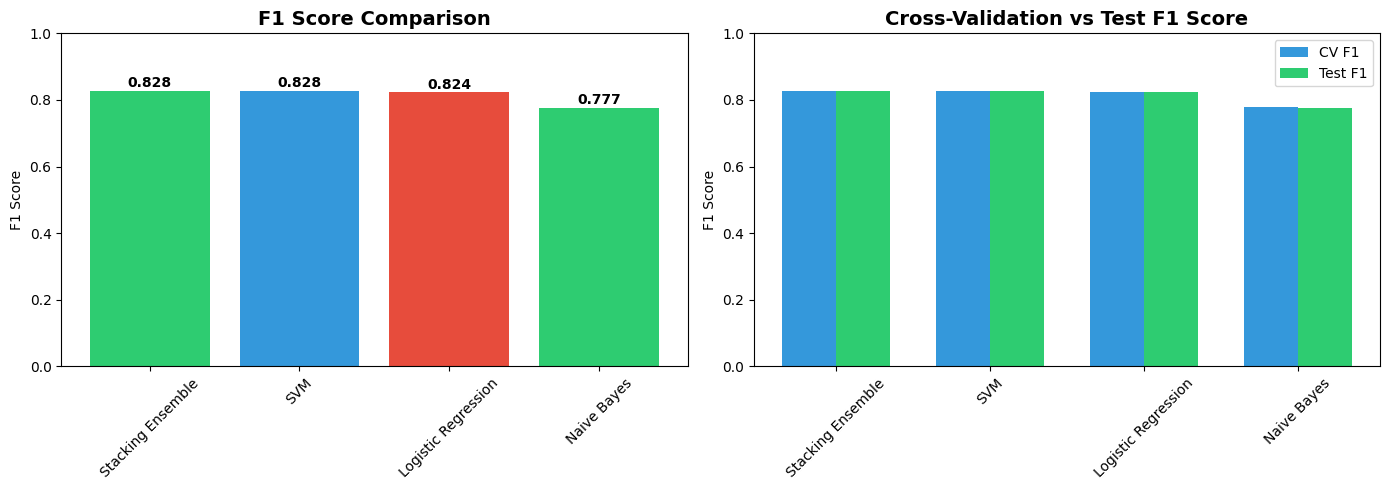

In [16]:
# Visualize results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 Score comparison
axes[0].bar(results_df['Model'], results_df['F1 Score'], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['F1 Score']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Cross-validation vs Test F1
x_pos = range(len(results_df))
width = 0.35
axes[1].bar([x - width/2 for x in x_pos], results_df['CV F1 Mean'], width, label='CV F1', color='#3498db')
axes[1].bar([x + width/2 for x in x_pos], results_df['F1 Score'], width, label='Test F1', color='#2ecc71')
axes[1].set_title('Cross-Validation vs Test F1 Score', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(results_df['Model'], rotation=45)
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 8. Best Model Selection & Detailed Evaluation

In [17]:
# Select best model based on F1 score
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\n  Best Model: {best_model_name}")
print(f"   F1 Score: {results_df.iloc[0]['F1 Score']:.4f}")
print(f"   Precision: {results_df.iloc[0]['Precision']:.4f}")
print(f"   Recall: {results_df.iloc[0]['Recall']:.4f}")
print(f"   Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")


  Best Model: Stacking Ensemble
   F1 Score: 0.8276
   Precision: 0.8277
   Recall: 0.8276
   Accuracy: 0.8276


In [18]:
# Detailed classification report for best model
y_pred_best = best_model.predict(X_test_tfidf)

print("\nDetailed Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_best, target_names=['Non-Toxic', 'Toxic']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Non-Toxic  Toxic")
print(f"Actual Non-Toxic    {cm[0,0]:5d}    {cm[0,1]:4d}")
print(f"       Toxic        {cm[1,0]:5d}    {cm[1,1]:4d}")


Detailed Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.83      0.82      0.83     72167
       Toxic       0.82      0.84      0.83     72611

    accuracy                           0.83    144778
   macro avg       0.83      0.83      0.83    144778
weighted avg       0.83      0.83      0.83    144778


Confusion Matrix:
                 Predicted
                 Non-Toxic  Toxic
Actual Non-Toxic    59184    12983
       Toxic        11970    60641


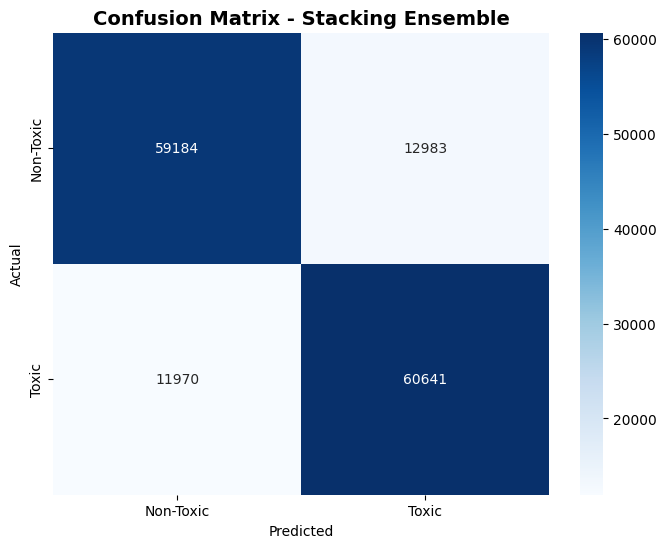

In [19]:
# Visualize confusion matrix
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Toxic', 'Toxic'],
            yticklabels=['Non-Toxic', 'Toxic'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 9. Save Model and Artifacts

In [6]:
# Save all trained models (use in-memory if available, otherwise load from disk)
import datetime, sklearn

# ── Load from disk if variables were lost (e.g. kernel restart) ───────────────
try:
    _ = trained_models
    _ = results_df
    _ = best_model
    _ = tfidf_vectorizer
    _ = X_train
    _ = X_test
    _ = df
    variables_ready = True
except NameError:
    variables_ready = False
    print("Variables not in memory — loading from saved files...")
    
    # Load models
    model_files = {
        "Logistic Regression": "logistic_regression.pkl",
        "Naive Bayes": "naive_bayes.pkl",
        "SVM": "svm.pkl",
        "Stacking Ensemble": "stacking_ensemble.pkl",
    }
    trained_models = {}
    for name, fname in model_files.items():
        path = MODELS_DIR / fname
        with open(path, 'rb') as f:
            trained_models[name] = pickle.load(f)
    
    # Load vectorizer
    with open(MODELS_DIR / "tfidf_vectorizer.pkl", 'rb') as f:
        tfidf_vectorizer = pickle.load(f)
    
    # Load summary / results
    with open(MODELS_DIR / "training_summary.json", 'r') as f:
        summary = json.load(f)
    
    results_df = pd.DataFrame(summary["all_models_results"])
    best_model_name = summary["best_model_name"]
    best_model = trained_models[best_model_name]
    
    # Restore dataset shapes from summary if possible
    X_train = None
    X_test = None
    df_shape = summary.get("dataset_shape_after_preprocessing", [723890, 3])
    class FakeDF:
        pass
    df = FakeDF()
    df.shape = tuple(df_shape)

# ── Save individual models ──────────────────────────────────────────────────
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    model_path = MODELS_DIR / f"{safe_name}.pkl"
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"  Saved: {model_path}")

# Save TF-IDF vectorizer
vectorizer_path = MODELS_DIR / "tfidf_vectorizer.pkl"
with open(vectorizer_path, 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print(f"  Saved: {vectorizer_path}")

# Save training summary (backward compatibility)
summary = {
    "best_model_name": best_model_name,
    "f1_score": float(results_df.iloc[0]['F1 Score']),
    "precision": float(results_df.iloc[0]['Precision']),
    "recall": float(results_df.iloc[0]['Recall']),
    "accuracy": float(results_df.iloc[0]['Accuracy']),
    "all_models_results": results_df.to_dict('records')
}

summary_path = MODELS_DIR / "training_summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"  Saved: {summary_path}")

# ─── 1. Save Model Metadata ──────────────────────────────────────────────────
metadata = {
    "project_name": "Hate Speech Detector",
    "task_type": "binary_classification",
    "best_model_name": best_model_name,
    "best_model_file": "stacking_ensemble.pkl",
    "vectorizer_file": "tfidf_vectorizer.pkl",
    "label_mapping": {"0": "Non-Toxic", "1": "Toxic"},
    "threshold": 0.5,
    "dataset_shape_before_preprocessing": [726119, 2],
    "dataset_shape_after_preprocessing": list(df.shape) if hasattr(df, 'shape') else [723890, 3],
    "train_size": int(len(X_train)) if X_train is not None else 579112,
    "test_size": int(len(X_test)) if X_test is not None else 144778,
    "random_state": RANDOM_STATE if 'RANDOM_STATE' in globals() else 42,
    "preprocessing_steps": [
        "lowercase",
        "url/html/mention/hashtag removal",
        "repeated character normalization",
        "punctuation removal",
        "non-alphabetic character removal",
        "word_tokenize",
        "stopword removal (english + custom)",
        "porter stemming",
        "remove tokens < 2 chars",
        "remove empty texts"
    ],
    "vectorizer_configuration": {
        "type": "FeatureUnion",
        "transformers": [
            {
                "name": "word",
                "type": "TfidfVectorizer",
                "analyzer": "word",
                "ngram_range": [1, 2],
                "max_features": 12000,
                "sublinear_tf": True,
                "min_df": 5,
                "max_df": 0.95
            },
            {
                "name": "char",
                "type": "TfidfVectorizer",
                "analyzer": "char_wb",
                "ngram_range": [3, 4],
                "max_features": 8000,
                "sublinear_tf": True,
                "min_df": 5,
                "max_df": 0.95
            }
        ]
    },
    "model_results": results_df.to_dict('records'),
    "best_model_metrics": {
        "F1 Score": float(results_df.iloc[0]['F1 Score']),
        "Precision": float(results_df.iloc[0]['Precision']),
        "Recall": float(results_df.iloc[0]['Recall']),
        "Accuracy": float(results_df.iloc[0]['Accuracy']),
        "ROC-AUC": float(results_df.iloc[0]['ROC-AUC']) if results_df.iloc[0]['ROC-AUC'] is not None else None,
    },
    "created_at": datetime.datetime.now().isoformat(),
    "sklearn_version": sklearn.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
}

metadata_path = MODELS_DIR / "model_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"  Saved: {metadata_path}")

# ─── 2. Save Deployment Artifact ─────────────────────────────────────────────
deployment_artifact = {
    "model": best_model,
    "vectorizer": tfidf_vectorizer,
    "metadata": metadata,
    "label_mapping": {"0": "Non-Toxic", "1": "Toxic"},
    "threshold": 0.5
}

artifact_path = MODELS_DIR / "deployment_artifact.pkl"
with open(artifact_path, 'wb') as f:
    pickle.dump(deployment_artifact, f)
print(f"  Saved: {artifact_path}")

Variables not in memory — loading from saved files...
  Saved: models\logistic_regression.pkl
  Saved: models\naive_bayes.pkl
  Saved: models\svm.pkl
  Saved: models\stacking_ensemble.pkl
  Saved: models\tfidf_vectorizer.pkl
  Saved: models\training_summary.json
  Saved: models\model_metadata.json
  Saved: models\deployment_artifact.pkl


In [13]:
print("=" * 70)
print("Verifying deployment_artifact.pkl reload...")
print("=" * 70)

# Load artifact
with open(MODELS_DIR / "deployment_artifact.pkl", 'rb') as f:
    artifact = pickle.load(f)

# Extract components
loaded_model = artifact["model"]
loaded_vectorizer = artifact["vectorizer"]
loaded_metadata = artifact["metadata"]
loaded_labels = artifact["label_mapping"]
loaded_threshold = artifact["threshold"]

print(f"Loaded model: {type(loaded_model).__name__}")
print(f"Label mapping: {loaded_labels}")
print(f"Threshold: {loaded_threshold}")
print(f"Metadata keys: {list(loaded_metadata.keys())}")

# Test predictions
print("\nTest Predictions:")
print("-" * 70)
test_texts = [
    "I love this community, everyone is so welcoming!",
    "You are such an idiot, I hate you so much!",
    "Go back to your country you stupid loser",
    "Have a wonderful day!"
]

for text in test_texts:
    processed = preprocess_text(text)
    features = loaded_vectorizer.transform([processed])
    prediction = loaded_model.predict(features)[0]
    
    if hasattr(loaded_model, "predict_proba"):
        proba = loaded_model.predict_proba(features)[0]
        toxic_prob = proba[1]
    else:
        toxic_prob = None
    
    label = loaded_labels.get(str(prediction), loaded_labels.get(prediction, "Unknown"))
    print(f"\nText: {text[:50]}...")
    print(f"  Prediction: {label}")
    if toxic_prob is not None:
        print(f"  Toxic Probability: {toxic_prob:.2%}")
        print(f"  Confidence: {max(toxic_prob, 1-toxic_prob):.2%}")

print("\n" + "=" * 70)
print("Artifact reload verified successfully!")
print("=" * 70)

Verifying deployment_artifact.pkl reload...
Loaded model: StackingClassifier
Label mapping: {'0': 'Non-Toxic', '1': 'Toxic'}
Threshold: 0.5
Metadata keys: ['project_name', 'task_type', 'best_model_name', 'best_model_file', 'vectorizer_file', 'label_mapping', 'threshold', 'dataset_shape_before_preprocessing', 'dataset_shape_after_preprocessing', 'train_size', 'test_size', 'random_state', 'preprocessing_steps', 'vectorizer_configuration', 'model_results', 'best_model_metrics', 'created_at', 'sklearn_version', 'numpy_version', 'pandas_version']

Test Predictions:
----------------------------------------------------------------------

Text: I love this community, everyone is so welcoming!...
  Prediction: Toxic
  Toxic Probability: 50.39%
  Confidence: 50.39%

Text: You are such an idiot, I hate you so much!...
  Prediction: Toxic
  Toxic Probability: 95.16%
  Confidence: 95.16%

Text: Go back to your country you stupid loser...
  Prediction: Toxic
  Toxic Probability: 95.41%
  Confidence:

## 10. Test Predictions

In [14]:
def predict_hate_speech(text, model=best_model, vectorizer=tfidf_vectorizer):
    """
    Predict if a text contains hate speech.
    Returns: prediction (0=Non-Toxic, 1=Toxic), probability
    """
    # Preprocess
    processed = preprocess_text(text)
    
    # Vectorize
    features = vectorizer.transform([processed])
    
    # Predict
    prediction = model.predict(features)[0]
    
    # Get probability if available
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(features)[0]
        toxic_prob = proba[1]
    else:
        toxic_prob = None
    
    return prediction, toxic_prob

# Test examples
test_examples = [
    "I love this community, everyone is so welcoming!",
    "You are such an idiot, I hate you so much!",
    "This is a great post, thanks for sharing!",
    "Go back to your country you stupid loser",
    "Have a wonderful day!"
]

print("Test Predictions:")
print("=" * 80)
for text in test_examples:
    pred, prob = predict_hate_speech(text)
    label = "TOXIC" if pred == 1 else "NON-TOXIC"
    if prob is not None:
        print(f"\nText: {text[:50]}...")
        print(f"Prediction: {label} (Confidence: {max(prob, 1-prob):.2%})")
    else:
        print(f"\nText: {text[:50]}...")
        print(f"Prediction: {label}")

Test Predictions:

Text: I love this community, everyone is so welcoming!...
Prediction: TOXIC (Confidence: 50.39%)

Text: You are such an idiot, I hate you so much!...
Prediction: TOXIC (Confidence: 95.16%)

Text: This is a great post, thanks for sharing!...
Prediction: NON-TOXIC (Confidence: 90.64%)

Text: Go back to your country you stupid loser...
Prediction: TOXIC (Confidence: 95.41%)

Text: Have a wonderful day!...
Prediction: NON-TOXIC (Confidence: 87.11%)


## Summary

This notebook implemented a complete hate speech detection pipeline:

1. **Data Preprocessing**: Lowercasing, punctuation/special char removal, stopword removal, stemming
2. **Feature Engineering**: FeatureUnion combining word TF-IDF (12k features, 1-2 grams) + character TF-IDF (8k features, 3-4 grams) = 20k total features
3. **Models**: Logistic Regression, Naive Bayes, SVM (Calibrated LinearSVC)
4. **Ensemble**: Stacking Ensemble using Logistic Regression, Naive Bayes, and Calibrated Linear SVC as base models, with Logistic Regression as the meta-classifier.
5. **Model Selection**: Best model selected based on F1-score
6. **Evaluation**: Precision, Recall, F1-score, ROC-AUC, Confusion Matrix

The trained model and vectorizer have been saved to the `models/` directory for use in the Streamlit application.